# EXP-003 — 6-mer lookup

**Гипотеза.** Две дополнительные upstream-буквы в слове [-5,0] содержат переносимый сигнал сверх 4-mer.

**Единственное изменение.** Только длина цельного слова: 4-mer → 6-mer.

**Reference.** EXP-002.

**Критерий принятия, зафиксированный до validation:** candidate
принимается, только если полный AP вырос минимум на 1% относительно,
EPIC Spearman не снизился и AP улучшился хотя бы на двух из трёх
validation-contig.

Официальный test не читается. Все основные метрики вычисляются на
полном `contig_holdout_v1`, без отрицательного subsampling.


## 1. Протокол серии до запуска

В EXP-002/003/004 меняется только длина `k`. Во всех notebooks
зафиксированы одинаковые:

- target `int(pooled_count > 0)`;
- train/validation-contig и seed 42;
- ориентация окна по предсказываемой цепи;
- цельное категориальное слово с последней буквой в offset `0`;
- `N/edge` как отдельная категория;
- train-only hierarchical backoff;
- точные full-population AP и dense-rank EPIC Spearman.

Здесь нет one-hot, solver, эпох и loss-кривой. Обучение — точный
подсчёт категорий и применение заранее заданной формулы сглаживания.
Вместо фиктивной training loss показываются support, shrinkage,
coverage и время полного прохода.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").is_file()
    and (candidate / "src/ml_project").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project.epic_baseline import (
    DinucleotideBaselineConfig,
    category_summary as dinucleotide_category_summary,
    evaluate_dinucleotide_baseline,
    fit_dinucleotide_baseline,
    load_baseline_sequences,
)
from ml_project.epic_data import ensure_prepared_split
from ml_project.epic_experiment import (
    ExperimentSpec,
    build_run_record,
    save_run_record,
)
from ml_project.epic_kmer import (
    KmerLookupConfig,
    SUPPORTED_K,
    evaluate_kmer_lookup,
    fit_kmer_lookup,
    kmer_category_labels,
    split_kmer_counts,
)

EXPERIMENT_ID = "EXP-003"
REFERENCE_K = 4
CANDIDATE_K = 6
CHAIN_KS = tuple(k for k in SUPPORTED_K if k <= CANDIDATE_K)
RUN_NAME = "run_001"

SPEC = ExperimentSpec(
    experiment_id=EXPERIMENT_ID,
    title="6-mer lookup",
    hypothesis="Две дополнительные upstream-буквы в слове [-5,0] содержат переносимый сигнал сверх 4-mer.",
    changed_variable="Только длина цельного слова: 4-mer → 6-mer.",
    success_criterion=(
        "relative validation AP gain >= 1%; candidate EPIC Spearman "
        ">= reference; AP improves on at least 2 of 3 validation contigs"
    ),
    seed=42,
)
CONFIG = KmerLookupConfig(
    ks=CHAIN_KS,
    smoothing="one_expected_positive",
)
NOTEBOOK_PATH = (
    PROJECT_ROOT / "notebooks/experiments/EXP-003_6mer_lookup.ipynb"
)
ARTIFACT_DIR = (
    PROJECT_ROOT / "artifacts/experiments" / EXPERIMENT_ID / RUN_NAME
)
PLOT_DIR = ARTIFACT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 40)
COLORS = {"reference": "#9AA0A6", "candidate": "#1967D2"}

def show_plot(fig, filename):
    path = PLOT_DIR / filename
    fig.savefig(path, dpi=170, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    return path

display(pd.Series({
    "python": platform.python_version(),
    "executable": sys.executable,
    "experiment": EXPERIMENT_ID,
    "reference_k": REFERENCE_K,
    "candidate_k": CANDIDATE_K,
    "chain": str(CHAIN_KS),
    "run": RUN_NAME,
}, name="value").to_frame())


,value
python,3.12.14
executable,C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\...
experiment,EXP-003
reference_k,4
candidate_k,6
chain,"(2, 4, 6)"
run,run_001


## 2. Неизменный data contract

Загружается тот же проверенный `contig_holdout_v1`, что в EXP-001.
Обе цепи каждого contig остаются вместе. Test показан только как
часть manifest; его target отсутствует и нигде далее не используется.


In [2]:
split = ensure_prepared_split(PROJECT_ROOT)
display(split.contig_assignment.sort_values(["split", "contig"]))
display(split.summary)
assert split.config.split_version == "contig_holdout_v1"


,contig,split,source_split
12,NC_064037.1,test,test
13,NC_064044.1,test,test
14,NC_064046.1,test,test
1,NC_064035.1,train,train
2,NC_064036.1,train,train
3,NC_064038.1,train,train
4,NC_064039.1,train,train
5,NC_064040.1,train,train
8,NC_064043.1,train,train
9,NC_064045.1,train,train


,split,contigs,intervals_both_strands,whitelist_bp,position_strand_count,percent_of_all_positions,positive_positions,negative_positions,positive_percent
0,train,9,168998,114032080,228064160,59.316784,170443.0,227893717.0,0.074735
1,validation,3,60386,41903743,83807486,21.797334,56205.0,83751281.0,0.067064
2,test,3,54846,36306695,72613390,18.885882,NaN,NaN,NaN


## 3. Что именно означает lookup и backoff

Для `k=6` одна категория — всё ориентированное слово
offsets `[-5, …, 0]`. На minus-цепи extractor
делает reverse-complement, поэтому смысл offsets одинаков на обеих
цепях. `N/edge` означает неизвестную букву либо край **contig**, а не
край whitelist-интервала.

Пусть `p` — train prevalence. До validation фиксируем
`tau = 1/p`, то есть prior содержит одну ожидаемую positive-позицию:

`score = (positive + tau × parent_score) / (total + tau)`.

Канонический backoff удаляет самые дальние upstream-буквы:
`8 → 6 → 4 → 2 → p`. Невстреченное слово получает ровно parent score.
У `N/edge` нет однозначного suffix, поэтому его prior всегда равен
глобальной train prevalence, но сама категория обучается по своим
counts. Validation не выбирает `tau` и не меняет формулу.


In [3]:
runtime_rows = []

started = time.monotonic()
sequences, fasta_alphabet = load_baseline_sequences(split)
runtime_rows.append({
    "stage": "load_fasta", "seconds": time.monotonic() - started
})

started = time.monotonic()
train_counts = split_kmer_counts(
    split,
    sequences,
    "train",
    ks=CHAIN_KS,
    batch_size=CONFIG.count_batch_size,
)
runtime_rows.append({
    "stage": "count_full_train", "seconds": time.monotonic() - started
})

started = time.monotonic()
validation_counts = split_kmer_counts(
    split,
    sequences,
    "validation",
    ks=CHAIN_KS,
    batch_size=CONFIG.count_batch_size,
)
runtime_rows.append({
    "stage": "count_full_validation",
    "seconds": time.monotonic() - started,
})

train_population = (
    train_counts.totals.groupby("k")["total_positions"].sum()
)
validation_population = (
    validation_counts.totals.groupby("k")["total_positions"].sum()
)
count_audit = pd.DataFrame({
    "k": CHAIN_KS,
    "possible_categories": [4**k + 1 for k in CHAIN_KS],
    "train_positions": [int(train_population.loc[k]) for k in CHAIN_KS],
    "train_positives": [len(train_counts.positives)] * len(CHAIN_KS),
    "validation_positions": [
        int(validation_population.loc[k]) for k in CHAIN_KS
    ],
    "validation_positives": [
        len(validation_counts.positives)
    ] * len(CHAIN_KS),
})
display(count_audit)

expected = split.summary.set_index("split")
assert count_audit["train_positions"].eq(
    int(expected.loc["train", "position_strand_count"])
).all()
assert count_audit["validation_positions"].eq(
    int(expected.loc["validation", "position_strand_count"])
).all()
print("Audit passed: каждый k покрывает полный train и validation.")


,k,possible_categories,train_positions,train_positives,validation_positions,validation_positives
0,2,17,228064160,170443,83807486,56205
1,4,257,228064160,170443,83807486,56205
2,6,4097,228064160,170443,83807486,56205


Audit passed: каждый k покрывает полный train и validation.


## 4. Train-only score tables

Эта операция не оптимизирует коэффициенты. Она применяет одну
зафиксированную формулу к полным category counts. В таблице support
особенно важны `zero_positive_categories`: их становится много у
8-mer, поэтому сырой rate без backoff был бы нестабилен.


In [4]:
started = time.monotonic()
fit = fit_kmer_lookup(train_counts, CONFIG)
runtime_rows.append({
    "stage": "fit_lookup_tables", "seconds": time.monotonic() - started
})

display(fit.smoothing_report)
display(fit.support_summary)

expected_tau = 1.0 / fit.global_prevalence
np.testing.assert_allclose(
    fit.smoothing_report["strength"].to_numpy(), expected_tau
)
assert fit.smoothing_report["method"].eq(
    "one_expected_positive"
).all()
print(f"Train prevalence: {fit.global_prevalence:.9f}")
print(f"Fixed tau: {expected_tau:.6f}")


,k,parent,method,strength,strength_lower_bound,strength_upper_bound,at_lower_bound,at_upper_bound,log_marginal_likelihood,optimizer_success,optimizer_message,formula
0,2,global prevalence,one_expected_positive,1338.067037,0.01,100000000.0,False,False,NaN,True,preregistered tau = 1 / train prevalence; one ...,(positive + strength * parent_score) / (total ...
1,4,2-mer suffix; N/edge uses global prevalence,one_expected_positive,1338.067037,0.01,100000000.0,False,False,NaN,True,preregistered tau = 1 / train prevalence; one ...,(positive + strength * parent_score) / (total ...
2,6,4-mer suffix; N/edge uses global prevalence,one_expected_positive,1338.067037,0.01,100000000.0,False,False,NaN,True,preregistered tau = 1 / train prevalence; one ...,(positive + strength * parent_score) / (total ...


,k,categories,observed_categories,unseen_categories,categories_with_positive,zero_positive_categories,total_positions,positive_positions,min_observed_support,median_observed_support,p10_observed_support,p90_observed_support,max_observed_support,smoothing_strength
0,2,17,17,0,17,0,228064160,170443,38118,13231627.0,8983194.2,20464729.0,23637240,1338.067037
1,4,257,257,0,257,0,228064160,170443,38351,821484.0,456765.0,1469739.0,3542187,1338.067037
2,6,4097,4097,0,4097,0,228064160,170443,13068,46534.0,24643.8,96579.8,597915,1338.067037


Train prevalence: 0.000747347
Fixed tau: 1338.067037


## 5. Точная полная validation-оценка

AP считается по category histogram с объединением одинаковых scores,
поэтому он в точности соответствует развёрнутым десяткам миллионов
строк. Spearman использует все положительные validation-позиции и
dense ranks исходного pooled count.

Scores остаются `float64` и не квантуются: это сохраняет протокол
EXP-001. Submission-aware rank transform и округление до пяти знаков
должны проверяться отдельным экспериментом.


In [5]:
started = time.monotonic()
evaluation = evaluate_kmer_lookup(validation_counts, fit)
runtime_rows.append({
    "stage": "evaluate_full_validation",
    "seconds": time.monotonic() - started,
})
runtime_report = pd.DataFrame(runtime_rows)

overall = evaluation.metric_summary.set_index("k")
reference_row = overall.loc[REFERENCE_K]
candidate_row = overall.loc[CANDIDATE_K]
pair_metric_summary = pd.DataFrame([
    {
        "metric": "Average Precision",
        "direction": "maximize",
        "reference": float(reference_row["average_precision"]),
        "candidate": float(candidate_row["average_precision"]),
        "delta": float(
            candidate_row["average_precision"]
            - reference_row["average_precision"]
        ),
        "relative_delta": float(
            candidate_row["average_precision"]
            / reference_row["average_precision"] - 1
        ),
    },
    {
        "metric": "EPIC Spearman",
        "direction": "maximize",
        "reference": float(reference_row["epic_spearman"]),
        "candidate": float(candidate_row["epic_spearman"]),
        "delta": float(
            candidate_row["epic_spearman"]
            - reference_row["epic_spearman"]
        ),
        "relative_delta": float(
            candidate_row["epic_spearman"]
            / reference_row["epic_spearman"] - 1
        ),
    },
])
display(
    pair_metric_summary.style.format({
        "reference": "{:.9f}",
        "candidate": "{:.9f}",
        "delta": "{:+.9f}",
        "relative_delta": "{:+.2%}",
    })
)
display(runtime_report.style.format({"seconds": "{:.3f}"}))


,metric,direction,reference,candidate,delta,relative_delta
0,Average Precision,maximize,0.001486787,0.001600537,+0.000113750,+7.65%
1,EPIC Spearman,maximize,0.094231830,0.097185572,+0.002953743,+3.13%


,stage,seconds
0,load_fasta,5.094
1,count_full_train,13.594
2,count_full_validation,4.765
3,fit_lookup_tables,0.031
4,evaluate_full_validation,0.265


### Bridge к EXP-001

В EXP-002 отдельно восстанавливается исходная L2 logistic regression
по тому же динуклеотиду. Если 2-mer lookup сохраняет тот же порядок
17 категорий, AP и Spearman совпадут. Эта проверка нужна, чтобы
изменение estimator не маскировалось под эффект длины слова.

В EXP-003/004 bridge уже не нужен: reference и candidate используют
один и тот же lookup estimator.


In [6]:
bridge_control = pd.DataFrame()
if EXPERIMENT_ID == "EXP-002":
    labels2 = dict(enumerate(kmer_category_labels(2)))
    train_dinuc_totals = train_counts.totals.loc[
        train_counts.totals["k"] == 2
    ].copy()
    train_dinuc_totals["category"] = (
        train_dinuc_totals["category_code"].map(labels2)
    )
    train_dinuc_positives = train_counts.positives.rename(
        columns={"kmer_2_code": "category_code"}
    ).copy()
    train_dinuc_positives["category"] = (
        train_dinuc_positives["category_code"].map(labels2)
    )
    train_dinuc_summary = dinucleotide_category_summary(
        train_dinuc_totals,
        train_dinuc_positives,
    )
    baseline_fit = fit_dinucleotide_baseline(
        train_dinuc_summary,
        DinucleotideBaselineConfig(),
    )

    validation_dinuc_totals = validation_counts.totals.loc[
        validation_counts.totals["k"] == 2
    ].copy()
    validation_dinuc_totals["category"] = (
        validation_dinuc_totals["category_code"].map(labels2)
    )
    validation_dinuc_positives = validation_counts.positives.rename(
        columns={"kmer_2_code": "category_code"}
    ).copy()
    validation_dinuc_positives["category"] = (
        validation_dinuc_positives["category_code"].map(labels2)
    )
    baseline_evaluation = evaluate_dinucleotide_baseline(
        validation_dinuc_totals,
        validation_dinuc_positives,
        baseline_fit,
        DinucleotideBaselineConfig(),
    )
    lr_metrics = baseline_evaluation.metric_summary.set_index("metric")
    lookup2 = overall.loc[2]
    bridge_control = pd.DataFrame([
        {
            "metric": "Average Precision",
            "EXP-001 logistic": lr_metrics.loc[
                "Average Precision", "candidate"
            ],
            "2-mer lookup": lookup2["average_precision"],
        },
        {
            "metric": "EPIC Spearman",
            "EXP-001 logistic": lr_metrics.loc[
                "EPIC Spearman", "candidate"
            ],
            "2-mer lookup": lookup2["epic_spearman"],
        },
    ])
    bridge_control["absolute_difference"] = (
        bridge_control["2-mer lookup"]
        - bridge_control["EXP-001 logistic"]
    ).abs()
    display(bridge_control.style.format({
        "EXP-001 logistic": "{:.12f}",
        "2-mer lookup": "{:.12f}",
        "absolute_difference": "{:.3g}",
    }))
    assert bridge_control["absolute_difference"].max() < 1e-12
else:
    print("Reference и candidate уже используют один lookup estimator.")


Reference и candidate уже используют один lookup estimator.


In [7]:
coverage_rows = []
for k in CHAIN_KS:
    train_table = fit.category_summary.loc[
        fit.category_summary["k"] == k
    ]
    validation_table = evaluation.category_summary.loc[
        evaluation.category_summary["k"] == k
    ]
    unseen = (
        (validation_table["train_total_positions"] == 0)
        & (validation_table["total_positions"] > 0)
    )
    coverage_rows.append({
        "k": k,
        "possible_categories": len(train_table),
        "train_observed_categories": int(train_table["observed"].sum()),
        "train_zero_positive_categories": int(
            ((train_table["total_positions"] > 0)
             & (train_table["positive_positions"] == 0)).sum()
        ),
        "validation_observed_categories": int(
            validation_table["observed"].sum()
        ),
        "validation_unseen_categories": int(unseen.sum()),
        "validation_positions_in_unseen": int(
            validation_table.loc[unseen, "total_positions"].sum()
        ),
        "unique_validation_score_levels": int(
            overall.loc[k, "unique_score_levels"]
        ),
    })
coverage_summary = pd.DataFrame(coverage_rows)
display(coverage_summary)


,k,possible_categories,train_observed_categories,train_zero_positive_categories,validation_observed_categories,validation_unseen_categories,validation_positions_in_unseen,unique_validation_score_levels
0,2,17,17,0,17,0,0,17
1,4,257,257,0,257,0,0,257
2,6,4097,4097,0,4097,0,0,4097


## 6. Основные метрики и стабильность по contig

AP и Spearman имеют разные шкалы, поэтому изображаются отдельно.
Per-contig линии соединяют один и тот же contig — это проверка, что
pooled-прирост не создаётся одной удержанной последовательностью.


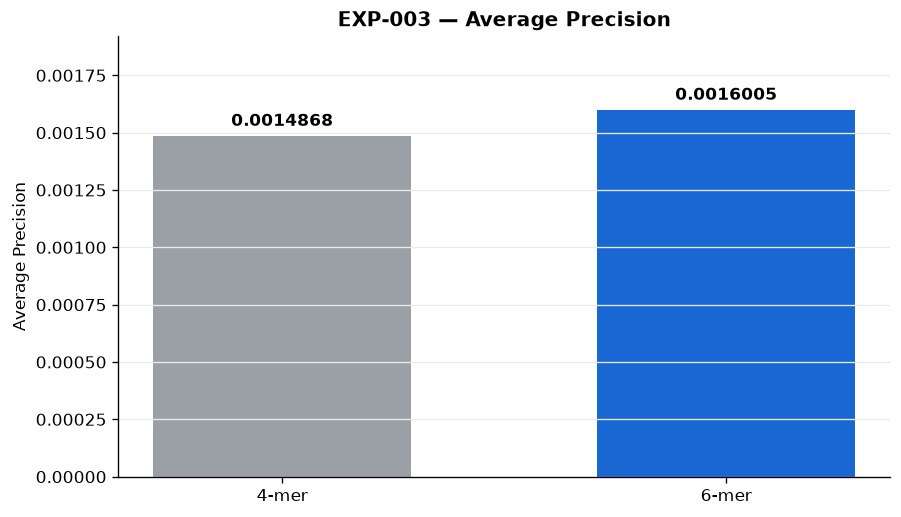

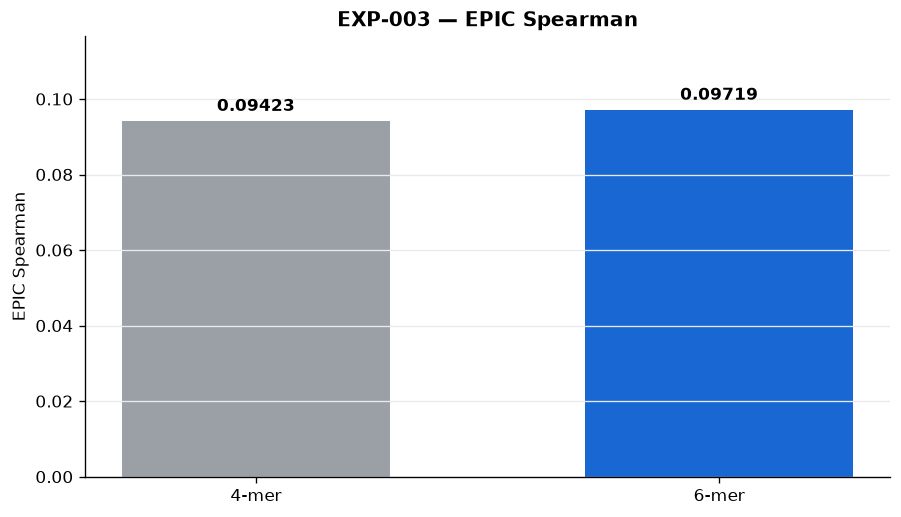

In [8]:
def metric_bar(metric, source_column, filename, decimals):
    values = [
        float(reference_row[source_column]),
        float(candidate_row[source_column]),
    ]
    labels = [f"{REFERENCE_K}-mer", f"{CANDIDATE_K}-mer"]
    colors = [COLORS["reference"], COLORS["candidate"]]
    fig, ax = plt.subplots(figsize=(7.4, 4.2), layout="constrained")
    bars = ax.bar(labels, values, color=colors, width=0.58)
    margin = max(values) * 0.20 if max(values) else 0.1
    ax.set_ylim(0, max(values) + margin)
    ax.set(ylabel=metric, title=f"{EXPERIMENT_ID} — {metric}")
    ax.grid(axis="y", color="#E8EAED", linewidth=0.8)
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            value + margin*0.08,
            f"{value:.{decimals}f}",
            ha="center", va="bottom", fontweight="bold",
        )
    show_plot(fig, filename)

metric_bar(
    "Average Precision", "average_precision",
    "01_average_precision.png", 7,
)
metric_bar(
    "EPIC Spearman", "epic_spearman",
    "02_epic_spearman.png", 5,
)


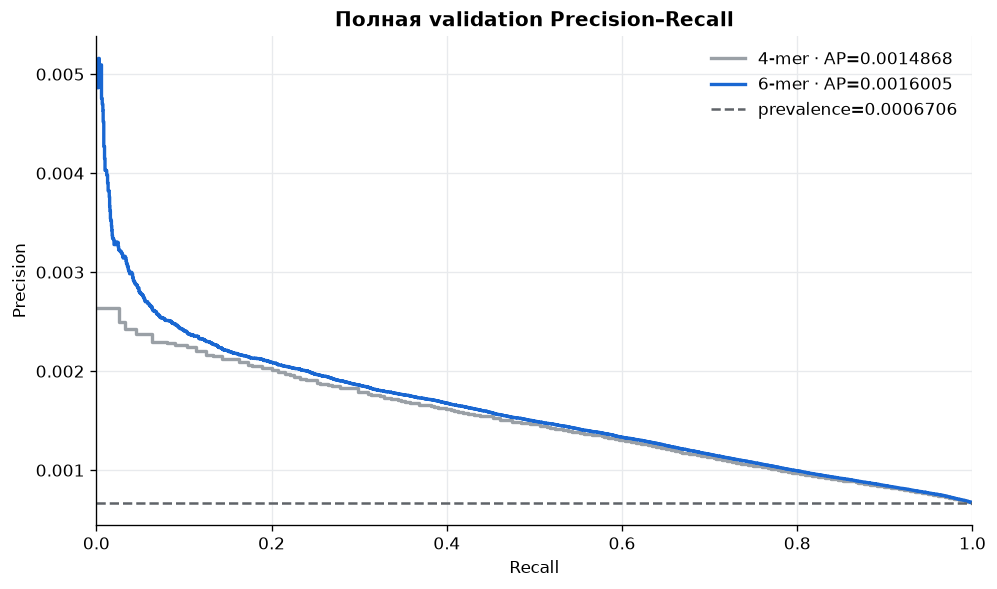

WindowsPath('D:/Projects/EPIC/EPIC/artifacts/experiments/EXP-003/run_001/plots/03_precision_recall.png')

In [9]:
fig, ax = plt.subplots(figsize=(8.2, 4.8), layout="constrained")
for k, color, label in (
    (REFERENCE_K, COLORS["reference"], f"{REFERENCE_K}-mer"),
    (CANDIDATE_K, COLORS["candidate"], f"{CANDIDATE_K}-mer"),
):
    curve = evaluation.precision_recall.loc[
        evaluation.precision_recall["k"] == k
    ].sort_values("recall")
    ap_value = float(overall.loc[k, "average_precision"])
    ax.step(
        np.r_[0.0, curve["recall"].to_numpy()],
        np.r_[curve["precision"].iloc[0], curve["precision"].to_numpy()],
        where="post", linewidth=2.0, color=color,
        label=f"{label} · AP={ap_value:.7f}",
    )
prevalence = float(candidate_row["prevalence"])
ax.axhline(
    prevalence, color="#5F6368", linestyle="--",
    label=f"prevalence={prevalence:.7f}",
)
ax.set(
    xlim=(0, 1), xlabel="Recall", ylabel="Precision",
    title="Полная validation Precision–Recall",
)
ax.grid(color="#E8EAED", linewidth=0.8)
ax.legend(frameon=False)
show_plot(fig, "03_precision_recall.png")


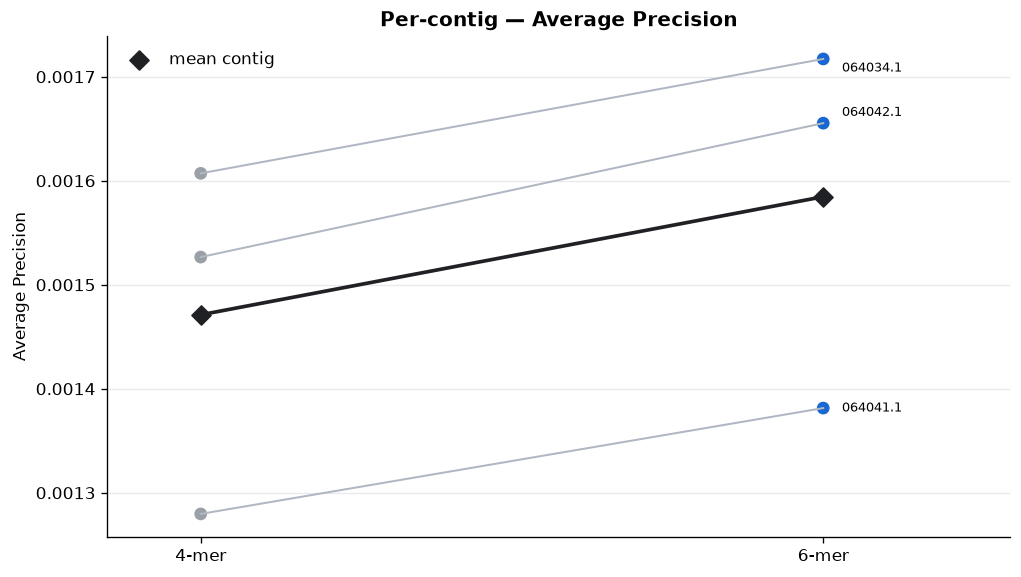

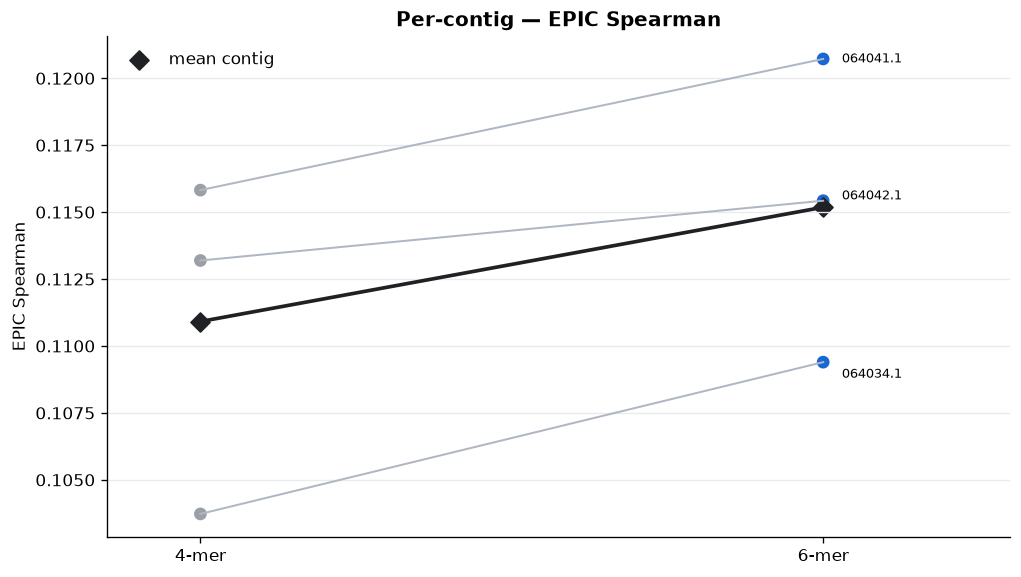

,segment,segment_value,k,variant,average_precision,epic_spearman,positions,positives,prevalence,unique_score_levels,metric_note
2,contig,NC_064034.1,4,4mer_lookup,0.001607,0.103728,33949114,23529,0.000693,257,exact full-whitelist evaluation with raw train...
3,contig,NC_064034.1,6,6mer_lookup,0.001717,0.109397,33949114,23529,0.000693,4097,exact full-whitelist evaluation with raw train...
6,contig,NC_064041.1,4,4mer_lookup,0.001280,0.115822,24146754,13984,0.000579,257,exact full-whitelist evaluation with raw train...
7,contig,NC_064041.1,6,6mer_lookup,0.001381,0.120721,24146754,13984,0.000579,4097,exact full-whitelist evaluation with raw train...
10,contig,NC_064042.1,4,4mer_lookup,0.001527,0.113193,25711618,18692,0.000727,257,exact full-whitelist evaluation with raw train...
11,contig,NC_064042.1,6,6mer_lookup,0.001655,0.115426,25711618,18692,0.000727,4097,exact full-whitelist evaluation with raw train...


In [10]:
per_contig = evaluation.per_contig_metrics.copy()

def paired_contig_plot(metric, filename, display_name):
    local = per_contig.loc[
        per_contig["k"].isin([REFERENCE_K, CANDIDATE_K])
    ]
    pivot = local.pivot(
        index="segment_value", columns="k", values=metric
    )
    fig, ax = plt.subplots(figsize=(8.4, 4.7), layout="constrained")
    for index, (contig, row) in enumerate(pivot.iterrows()):
        y = [row[REFERENCE_K], row[CANDIDATE_K]]
        ax.plot([0, 1], y, color="#B0B7C3", linewidth=1.2)
        ax.scatter(
            [0, 1], y,
            color=[COLORS["reference"], COLORS["candidate"]],
            s=44,
        )
        offset = (index - (len(pivot)-1)/2) * max(np.ptp(y), 1e-8) * 0.08
        ax.text(
            1.03, y[1] + offset,
            str(contig).replace("NC_", ""), va="center", fontsize=8,
        )
    means = [pivot[REFERENCE_K].mean(), pivot[CANDIDATE_K].mean()]
    ax.plot([0, 1], means, color="#202124", linewidth=2.2)
    ax.scatter(
        [0, 1], means, color="#202124", marker="D", s=65,
        label="mean contig",
    )
    ax.set_xticks([0, 1], [f"{REFERENCE_K}-mer", f"{CANDIDATE_K}-mer"])
    ax.set_xlim(-0.15, 1.30)
    ax.set(ylabel=display_name, title=f"Per-contig — {display_name}")
    ax.grid(axis="y", color="#E8EAED", linewidth=0.8)
    ax.legend(frameon=False)
    show_plot(fig, filename)
    return pivot

contig_ap = paired_contig_plot(
    "average_precision", "04_contig_average_precision.png",
    "Average Precision",
)
contig_spearman = paired_contig_plot(
    "epic_spearman", "05_contig_epic_spearman.png",
    "EPIC Spearman",
)
display(
    per_contig.loc[
        per_contig["k"].isin([REFERENCE_K, CANDIDATE_K])
    ]
)


## 7. Support и действие сглаживания

У цельного k-mer нет переноса информации между всеми похожими
словами. Backoff делится только с конечным более коротким suffix.
`data_weight = n/(n+tau)` показывает, насколько итоговый score
определяется собственной статистикой категории, а не prior.


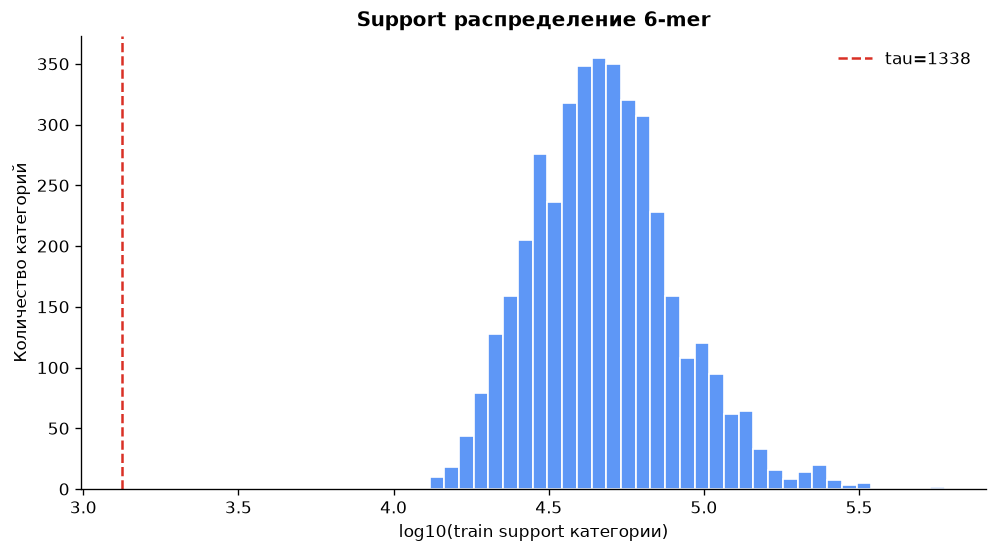

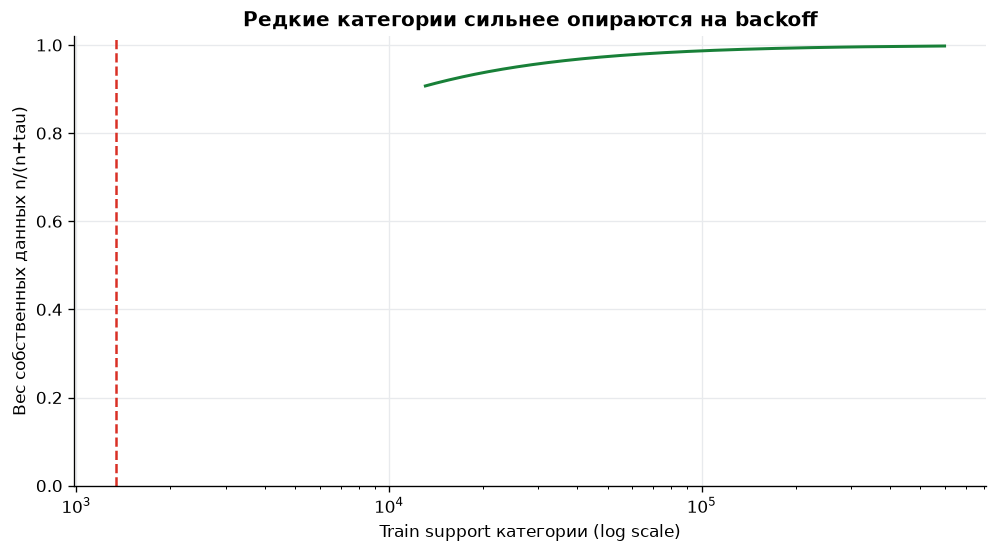

WindowsPath('D:/Projects/EPIC/EPIC/artifacts/experiments/EXP-003/run_001/plots/07_shrinkage_vs_support.png')

In [11]:
candidate_train = fit.category_summary.loc[
    fit.category_summary["k"] == CANDIDATE_K
].copy()
observed_candidate = candidate_train.loc[
    candidate_train["total_positions"] > 0
].copy()

fig, ax = plt.subplots(figsize=(8.2, 4.5), layout="constrained")
ax.hist(
    np.log10(observed_candidate["total_positions"]),
    bins=35, color="#5E97F6", edgecolor="white",
)
ax.axvline(
    np.log10(expected_tau), color="#D93025", linestyle="--",
    label=f"tau={expected_tau:.0f}",
)
ax.set(
    xlabel="log10(train support категории)",
    ylabel="Количество категорий",
    title=f"Support распределение {CANDIDATE_K}-mer",
)
ax.legend(frameon=False)
show_plot(fig, "06_category_support.png")

ordered_support = observed_candidate.sort_values("total_positions")
fig, ax = plt.subplots(figsize=(8.2, 4.5), layout="constrained")
ax.plot(
    ordered_support["total_positions"],
    ordered_support["data_weight"],
    color="#188038", linewidth=1.8,
)
ax.axvline(expected_tau, color="#D93025", linestyle="--")
ax.set_xscale("log")
ax.set(
    xlabel="Train support категории (log scale)",
    ylabel="Вес собственных данных n/(n+tau)",
    title="Редкие категории сильнее опираются на backoff",
    ylim=(0, 1.02),
)
ax.grid(color="#E8EAED", linewidth=0.8)
show_plot(fig, "07_shrinkage_vs_support.png")


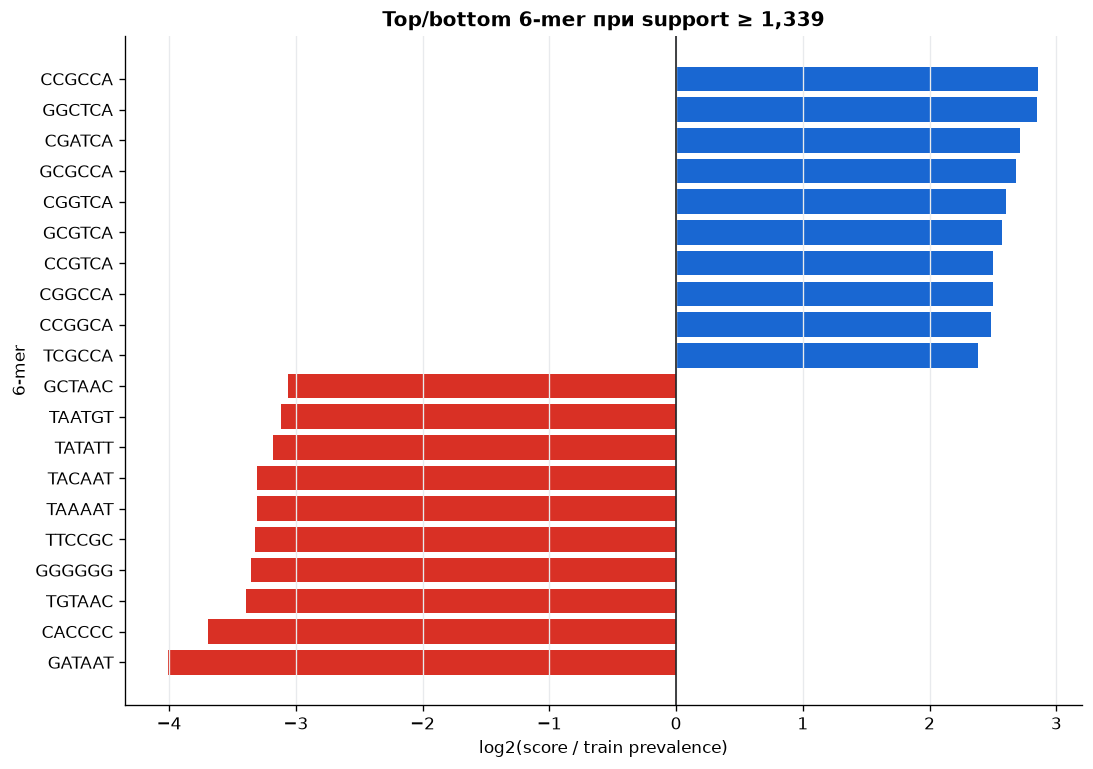

,category,group,total_positions,positive_positions,positive_rate,prior_score,posterior_score,score_enrichment
2517,GATAAT,bottom,88481,4,0.000045,0.000136,0.000047,0.062298
1383,CACCCC,bottom,54641,3,0.000055,0.000177,0.000058,0.077374
4051,TGTAAC,bottom,57753,4,0.000069,0.000153,0.000071,0.095197
3004,GGGGGG,bottom,129571,9,0.000069,0.000421,0.000073,0.097749
4203,TTCCGC,bottom,29634,2,0.000067,0.000237,0.000075,0.100080
3349,TAAAAT,bottom,213789,16,0.000075,0.000196,0.000076,0.101152
3413,TACAAT,bottom,93710,7,0.000075,0.000145,0.000076,0.101279
3553,TATATT,bottom,146348,12,0.000082,0.000151,0.000083,0.110559
3405,TAATGT,bottom,85783,7,0.000082,0.000379,0.000086,0.115293
2771,GCTAAC,bottom,34383,3,0.000087,0.000153,0.000090,0.120020


In [12]:
minimum_support = max(int(np.ceil(expected_tau)), 1_000)
stable_categories = candidate_train.loc[
    (candidate_train["total_positions"] >= minimum_support)
    & (candidate_train["category"] != "N/edge")
].copy()
stable_categories["score_enrichment"] = (
    stable_categories["posterior_score"] / fit.global_prevalence
)
stable_categories["log2_score_enrichment"] = np.log2(
    stable_categories["score_enrichment"]
)
top_bottom = pd.concat([
    stable_categories.nsmallest(10, "posterior_score").assign(group="bottom"),
    stable_categories.nlargest(10, "posterior_score").assign(group="top"),
]).sort_values("log2_score_enrichment")

fig, ax = plt.subplots(figsize=(9.0, 6.3), layout="constrained")
colors = np.where(
    top_bottom["log2_score_enrichment"] >= 0,
    "#1967D2", "#D93025",
)
ax.barh(
    top_bottom["category"],
    top_bottom["log2_score_enrichment"],
    color=colors,
)
ax.axvline(0, color="#202124", linewidth=1)
ax.set(
    xlabel="log2(score / train prevalence)",
    ylabel=f"{CANDIDATE_K}-mer",
    title=f"Top/bottom {CANDIDATE_K}-mer при support ≥ {minimum_support:,}",
)
ax.grid(axis="x", color="#E8EAED", linewidth=0.8)
show_plot(fig, "08_top_bottom_kmers.png")
display(top_bottom[[
    "category", "group", "total_positions", "positive_positions",
    "positive_rate", "prior_score", "posterior_score",
    "score_enrichment",
]])


## 8. История серии и внешний ориентир `epic_solution`

External числа читаются из единой таблицы
`phase2_nematostella_results.csv`. Они получены на official test
halves с другим split и score transform. Поэтому они показаны
отдельно, не участвуют в delta, критерии или решении и не позволяют
утверждать, что одна локальная модель «победила» другую.


,k,model,external_average_precision,external_epic_spearman,protocol
0,2,dinucleotide (challenge baseline),0.00122,0.0810,external official test halves; different split...
1,4,4-mer,0.00134,0.1023,external official test halves; different split...
2,6,6-mer,0.00148,0.1183,external official test halves; different split...
3,8,8-mer,0.00150,0.1316,external official test halves; different split...


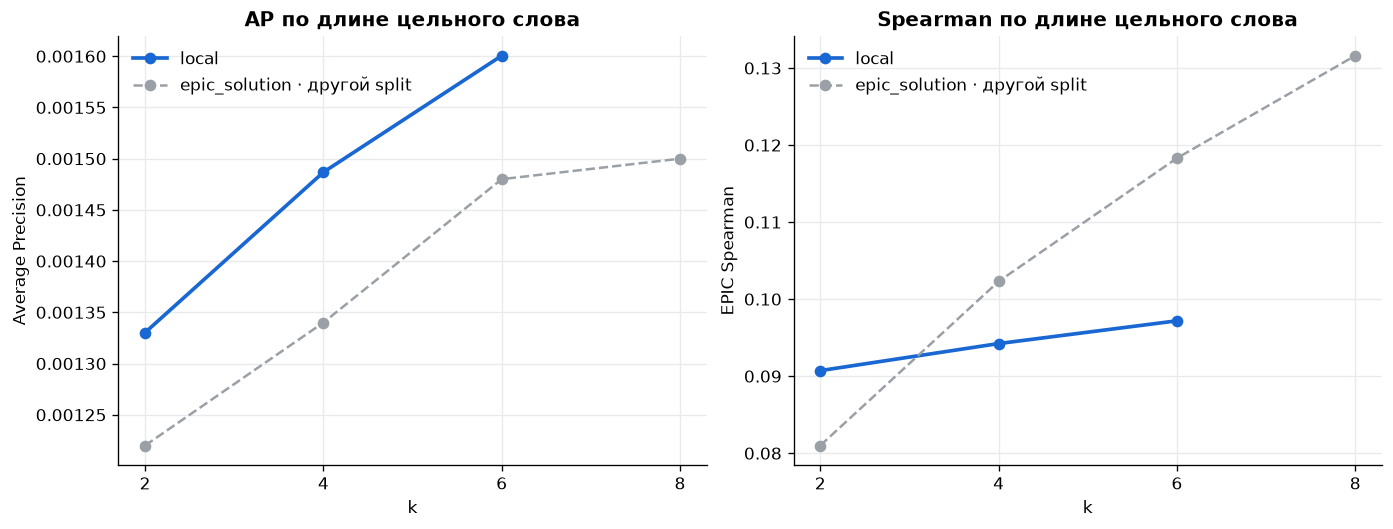

WindowsPath('D:/Projects/EPIC/EPIC/artifacts/experiments/EXP-003/run_001/plots/09_kmer_history_and_external.png')

In [13]:
external_path = (
    PROJECT_ROOT.parent
    / "epic_solution/results/phase2_nematostella_results.csv"
)
external_expected = pd.DataFrame({
    "k": [2, 4, 6, 8],
    "model": ["dinucleotide (challenge baseline)", "4-mer", "6-mer", "8-mer"],
    "external_average_precision": [0.00122, 0.00134, 0.00148, 0.00150],
    "external_epic_spearman": [0.0810, 0.1023, 0.1183, 0.1316],
})
if external_path.is_file():
    raw_external = pd.read_csv(external_path)
    selected = raw_external.loc[
        raw_external["model"].isin(external_expected["model"])
    ].set_index("model")
    external_benchmark = external_expected[["k", "model"]].copy()
    external_benchmark["external_average_precision"] = (
        external_benchmark["model"].map(selected["prauc_mean"])
    )
    external_benchmark["external_epic_spearman"] = (
        external_benchmark["model"].map(selected["spear_mean"])
    )
    external_sha256 = hashlib.sha256(external_path.read_bytes()).hexdigest()
else:
    external_benchmark = external_expected.copy()
    external_sha256 = None
external_benchmark["protocol"] = (
    "external official test halves; different split and transform"
)
display(external_benchmark)

local_history = evaluation.metric_summary.loc[
    evaluation.metric_summary["k"] > 0,
    ["k", "average_precision", "epic_spearman"],
].copy()
local_history["protocol"] = "local contig_holdout_v1 full validation"

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), layout="constrained")
axes[0].plot(
    local_history["k"], local_history["average_precision"],
    marker="o", linewidth=2.2, color="#1967D2", label="local",
)
axes[0].plot(
    external_benchmark["k"],
    external_benchmark["external_average_precision"],
    marker="o", linestyle="--", color="#9AA0A6",
    label="epic_solution · другой split",
)
axes[0].set(
    xlabel="k", ylabel="Average Precision",
    title="AP по длине цельного слова",
)
axes[1].plot(
    local_history["k"], local_history["epic_spearman"],
    marker="o", linewidth=2.2, color="#1967D2", label="local",
)
axes[1].plot(
    external_benchmark["k"],
    external_benchmark["external_epic_spearman"],
    marker="o", linestyle="--", color="#9AA0A6",
    label="epic_solution · другой split",
)
axes[1].set(
    xlabel="k", ylabel="EPIC Spearman",
    title="Spearman по длине цельного слова",
)
for ax in axes:
    ax.set_xticks([2, 4, 6, 8])
    ax.grid(color="#E8EAED", linewidth=0.8)
    ax.legend(frameon=False)
show_plot(fig, "09_kmer_history_and_external.png")


## 9. Механическое решение

Decision не выбирается по впечатлению от графика. Ниже буквально
применяются три условия, записанные в начале notebook. Даже если
более длинное слово имеет чуть лучший pooled AP, оно отклоняется,
если прирост меньше заранее заданного порога или ухудшает вторичную
обязательную метрику.


In [14]:
reference_ap = float(reference_row["average_precision"])
candidate_ap = float(candidate_row["average_precision"])
reference_spearman = float(reference_row["epic_spearman"])
candidate_spearman = float(candidate_row["epic_spearman"])
relative_ap_gain = candidate_ap / reference_ap - 1
contig_ap_wins = int((
    contig_ap[CANDIDATE_K] > contig_ap[REFERENCE_K]
).sum())

success_checks = pd.Series({
    "relative AP gain >= 1%": relative_ap_gain >= 0.01,
    "EPIC Spearman не ниже reference": (
        candidate_spearman >= reference_spearman
    ),
    "AP выше минимум на 2/3 contig": contig_ap_wins >= 2,
}, name="passed")
display(success_checks.to_frame())

success = bool(success_checks.all())
DECISION = "adopt" if success else "reject"
INTERPRETATION = (
    f"{CANDIDATE_K}-mer изменил полный validation AP с "
    f"{reference_ap:.9f} до {candidate_ap:.9f} "
    f"({relative_ap_gain:+.2%}) и EPIC Spearman с "
    f"{reference_spearman:.6f} до {candidate_spearman:.6f}. "
    f"AP улучшился на {contig_ap_wins} из 3 validation-contig. "
    f"По заранее заданному правилу решение: {DECISION}."
)

current_best = local_history.loc[
    local_history["average_precision"].idxmax()
]
within_one_percent = local_history.loc[
    local_history["average_precision"]
    >= 0.99 * current_best["average_precision"]
]
series_candidates = within_one_percent.loc[
    within_one_percent["epic_spearman"]
    >= current_best["epic_spearman"]
]
recommended_k_so_far = (
    int(series_candidates["k"].min())
    if not series_candidates.empty else None
)
display(Markdown(
    f"**Decision: `{DECISION}`.** {INTERPRETATION}  \n"
    f"Текущий shortest-near-best выбор в рассчитанной цепочке: "
    f"`k={recommended_k_so_far}`."
))


,passed
relative AP gain >= 1%,True
EPIC Spearman не ниже reference,True
AP выше минимум на 2/3 contig,True


**Decision: `adopt`.** 6-mer изменил полный validation AP с 0.001486787 до 0.001600537 (+7.65%) и EPIC Spearman с 0.094232 до 0.097186. AP улучшился на 3 из 3 validation-contig. По заранее заданному правилу решение: adopt.  
Текущий shortest-near-best выбор в рассчитанной цепочке: `k=6`.

## 10. Сохранение запуска

Сохраняются обе обязательные метрики, category lookup, coverage,
support, positive predictions, PR points, runtime, внешний ориентир,
все графики и metadata с полным data contract. `run_001` не
перезаписывается: изменение протокола требует нового run name.


In [15]:
train_candidate_summary = fit.category_summary.loc[
    fit.category_summary["k"] == CANDIDATE_K
].copy()
validation_candidate_summary = evaluation.category_summary.loc[
    evaluation.category_summary["k"] == CANDIDATE_K
].copy()
lookup_table = train_candidate_summary[[
    "k", "category_code", "category", "total_positions",
    "positive_positions", "positive_rate", "parent_k",
    "parent_category_code", "prior_score", "smoothing_strength",
    "data_weight", "posterior_score",
]]

tables = {
    "metric_summary.csv": pair_metric_summary,
    "all_k_metrics.csv": evaluation.metric_summary,
    "per_contig_metrics.csv": evaluation.per_contig_metrics,
    "train_kmer_summary.csv": train_candidate_summary,
    "validation_kmer_summary.csv": validation_candidate_summary,
    "lookup_table.csv": lookup_table,
    "coverage_summary.csv": coverage_summary,
    "support_summary.csv": fit.support_summary,
    "smoothing_report.csv": fit.smoothing_report,
    "top_bottom_kmers.csv": top_bottom,
    "precision_recall.csv": evaluation.precision_recall,
    "runtime_report.csv": runtime_report,
    "kmer_history.csv": local_history,
    "external_benchmark.csv": external_benchmark,
}
if not bridge_control.empty:
    tables["exp001_bridge_control.csv"] = bridge_control
for filename, table in tables.items():
    table.to_csv(ARTIFACT_DIR / filename, index=False)
evaluation.positive_predictions.to_csv(
    ARTIFACT_DIR / "positive_predictions.csv.gz",
    index=False,
    compression="gzip",
)

METRICS = {
    "reference_average_precision": reference_ap,
    "candidate_average_precision": candidate_ap,
    "delta_average_precision": candidate_ap - reference_ap,
    "reference_epic_spearman": reference_spearman,
    "candidate_epic_spearman": candidate_spearman,
    "delta_epic_spearman": candidate_spearman - reference_spearman,
}
EXPERIMENT_PARAMETERS = CONFIG.to_dict() | {
    "reference_k": REFERENCE_K,
    "candidate_k": CANDIDATE_K,
    "backoff_chain": list(CHAIN_KS),
    "actual_tau": float(expected_tau),
    "tau_rule": "1 / full train prevalence; one expected positive",
    "n_edge_prior": "global train prevalence",
    "reference_experiment": "EXP-002",
    "external_benchmark_path": str(external_path),
    "external_benchmark_sha256": external_sha256,
    "external_benchmark_used_for_decision": False,
    "validation_population": "all whitelist positions",
    "score_quantisation": "none; raw float64 train-only posterior rates",
}
record = build_run_record(
    SPEC,
    split,
    run_name=RUN_NAME,
    notebook_path=NOTEBOOK_PATH,
    parameters=EXPERIMENT_PARAMETERS,
    metrics=METRICS,
    interpretation=INTERPRETATION,
    decision=DECISION,
)
output = save_run_record(PROJECT_ROOT, record)
(output / "config.json").write_text(
    json.dumps(EXPERIMENT_PARAMETERS, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
print("Saved run:", output)
for path in sorted(output.rglob("*")):
    if path.is_file():
        print(" -", path.relative_to(PROJECT_ROOT))


Saved run: D:\Projects\EPIC\EPIC\artifacts\experiments\EXP-003\run_001
 - artifacts\experiments\EXP-003\run_001\all_k_metrics.csv
 - artifacts\experiments\EXP-003\run_001\config.json
 - artifacts\experiments\EXP-003\run_001\coverage_summary.csv
 - artifacts\experiments\EXP-003\run_001\external_benchmark.csv
 - artifacts\experiments\EXP-003\run_001\kmer_history.csv
 - artifacts\experiments\EXP-003\run_001\lookup_table.csv
 - artifacts\experiments\EXP-003\run_001\metadata.json
 - artifacts\experiments\EXP-003\run_001\metric_summary.csv
 - artifacts\experiments\EXP-003\run_001\metrics.csv
 - artifacts\experiments\EXP-003\run_001\per_contig_metrics.csv
 - artifacts\experiments\EXP-003\run_001\plots\01_average_precision.png
 - artifacts\experiments\EXP-003\run_001\plots\02_epic_spearman.png
 - artifacts\experiments\EXP-003\run_001\plots\03_precision_recall.png
 - artifacts\experiments\EXP-003\run_001\plots\04_contig_average_precision.png
 - artifacts\experiments\EXP-003\run_001\plots\05_con